# Setup

In [1]:
import sys
sys.path.append('/home/simon/Work/morphometry')
import importlib

import numpy as np
import morphometry.hip as hip
import morphometry.image_io as io
import morphometry.utils as utils
import pyvista as pv
import nibabel as nib
from sklearn.cluster import KMeans
from scipy.spatial import KDTree
from scipy.ndimage import center_of_mass
from matplotlib import pyplot as plt

In [2]:
seg = io.Segmentation('nibabel')
seg.read_image('/home/simon/Data/NMDID/test_combined_hip.nii.gz')
seg.transform_coordinate_system()

In [3]:
left_image = seg.array[:seg.shape[0] // 2]
right_image = seg.array[seg.shape[0] // 2:]
left_leg = nib.Nifti1Image(left_image, seg.affine, seg.header)
left_leg = io.Segmentation.from_nibabel(left_leg)
right_leg = nib.Nifti1Image(right_image, seg.affine, seg.header)
right_leg = io.Segmentation.from_nibabel(right_leg)
x_ratio = abs(seg.spacing[2]) / (2 * abs(seg.spacing[0]))

# CCD

In [4]:
mask = np.where(left_leg.array == 1, 1, 0)
contour_points = utils.get_contour_points(mask)
femur_contour = utils.get_contour_points(mask)
# femur_contour = femur_contour.astype(np.float32) * np.array([1, 1, x_ratio])

## Femoral Head Center

In [5]:
layer_high = np.amin(contour_points[:, 2])
com_high = utils.center_of_mass(mask[:, :, layer_high])
com_high = (int(com_high[0]), com_high[1])
com_high = (int(com_high[0]), int(com_high[1]))
layer_low = layer_high + 1

while mask[com_high[0], com_high[1], layer_low] != 0:
    layer_low += 1

contour_points = contour_points[contour_points[:, 2] >= layer_high]
contour_points = contour_points[contour_points[:, 2] <= layer_low]

In [6]:
contour_points = np.array([left_leg.transform_index_to_physical_point(x) for x in contour_points])
femur_contour = np.array([left_leg.transform_index_to_physical_point(x) for x in femur_contour])
layer_high = left_leg.transform_index_to_physical_point((0, 0, layer_high))[2]
layer_low = left_leg.transform_index_to_physical_point((0, 0, layer_low))[2]
com_high = left_leg.transform_index_to_physical_point((com_high[0], com_high[1], 0))[:2]

In [7]:
p = pv.Plotter()
p.add_mesh(pv.PolyData(femur_contour))
p.add_mesh(pv.PolyData(contour_points), color='red')
p.show()

Widget(value='<iframe src="http://localhost:39567/index.html?ui=P_0x75a262c342e0_0&reconnect=auto" class="pyvi…

In [8]:
# contour_points = contour_points.astype(np.float32) * np.array([1, 1, x_ratio])
# middle_slice = (layer_high * x_ratio + (layer_low * x_ratio - layer_high * x_ratio) // 2)
middle_slice = (layer_high + (layer_low - layer_high) // 2)
superior_half = contour_points[contour_points[:, 2] >= middle_slice]
# max_s = np.max(superior_half[:, 0])
min_s = np.min(superior_half[:, 0])
# radius = max_s - com_high[0]
radius = com_high[0] - min_s
# min_s = com_high[0] - radius
max_s = com_high[0] + radius
# contour_points = contour_points[contour_points[:, 0] >= min_s]
contour_points = contour_points[contour_points[:, 0] <= max_s]

In [9]:
p = pv.Plotter()
p.add_mesh(pv.PolyData(femur_contour))
p.add_mesh(pv.PolyData(contour_points), color='red')
# p.add_mesh(pv.PolyData(superior_half), color='red')
p.show()

Widget(value='<iframe src="http://localhost:39567/index.html?ui=P_0x75a25eb9e1d0_1&reconnect=auto" class="pyvi…

In [10]:
min_c = np.min(contour_points[:, 1])
radius = com_high[1] - min_c
max_c = com_high[1] + radius
contour_points = contour_points[contour_points[:, 1] <= max_c]

In [11]:
p = pv.Plotter()
p.add_mesh(pv.PolyData(femur_contour))
p.add_mesh(pv.PolyData(contour_points), color='red')
p.show()

Widget(value='<iframe src="http://localhost:39567/index.html?ui=P_0x75a25ec61c00_2&reconnect=auto" class="pyvi…

In [12]:
r, center = utils.sphere_fit(contour_points)

In [13]:
p = pv.Plotter()
p.add_mesh(pv.PolyData(femur_contour))
p.add_mesh(pv.PolyData(contour_points), color='red')
p.add_mesh(pv.Sphere(radius=r, center=center), style='wireframe', color='green', opacity=0.5)
p.show()

Widget(value='<iframe src="http://localhost:39567/index.html?ui=P_0x75a25ec619c0_3&reconnect=auto" class="pyvi…

## Femoral Neck Center

In [14]:
solid_sphere = pv.SolidSphere(inner_radius=r, outer_radius=1.2*r, center=center)
points_i_want = np.array(solid_sphere.points)
points_i_want = points_i_want[points_i_want[:, 2] < center[2]]
points_i_want = points_i_want[points_i_want[:, 0] > center[0]]

In [15]:
com = KMeans(n_clusters=1).fit(points_i_want).cluster_centers_[0]
distances = np.linalg.norm(points_i_want - com, axis=1)
points_i_want = points_i_want[distances <= distances.mean() + 1.5 * distances.std()]

In [16]:
pc_tree = KDTree(femur_contour)
sphere_tree = KDTree(points_i_want)

In [17]:
pairs = sphere_tree.query_ball_tree(pc_tree, 2)
neck_points = list()
for pair in pairs:
    if len(pair) > 0:
        for index in pair:
            neck_points.append(femur_contour[index])
neck_points = np.array(neck_points)

In [18]:
com = KMeans(n_clusters=1).fit(neck_points).cluster_centers_[0]
com = np.array(com)

In [19]:
p = pv.Plotter()
p.add_mesh(pv.PolyData(femur_contour))
p.add_mesh(pv.PolyData(neck_points), color='red')
p.add_mesh(pv.Sphere(radius=20, center=com), style='wireframe', opacity=0.5)
p.show()

Widget(value='<iframe src="http://localhost:39567/index.html?ui=P_0x75a23c1458a0_4&reconnect=auto" class="pyvi…

## Implementation Test

In [20]:
import importlib
importlib.reload(hip)

<module 'morphometry.hip' from '/home/simon/Work/morphometry/morphometry/hip.py'>

In [21]:
p = pv.Plotter()
print(hip.calculate_ccd_ct(left_leg, 'left', 1, p))
print(hip.calculate_ccd_ct(right_leg, 'right', 1, p))
p.show()

(141.46157319519105, 142.59833763837034)
(147.8343859647253, 152.27979176946812)


Widget(value='<iframe src="http://localhost:39567/index.html?ui=P_0x75a25e086f80_5&reconnect=auto" class="pyvi…

# Femoral Torsion

In [22]:
import morphometry.femur as femur
from matplotlib import pyplot as plt

## Proximal Reference Line

In [23]:
hip_start = np.min(np.argwhere(left_leg.array == 1)[:, 2])  # get the most proximal slice of the femur
femur_end = np.max(np.argwhere(left_leg.array == 1)[:, 2])  # get the most distal slice of the femur
num_femur_slices = femur_end - hip_start + 1
hip_end = hip_start + int(0.3 * num_femur_slices)
hip_mask = left_leg.array.copy()
hip_mask[:, :, :hip_start] = 0
hip_mask[:, :, hip_end + 1:] = 0

In [30]:
_, masks = io.split_ct_image(left_leg, None)

Hip slices: 139 to 197, Knee slices: 319 to 338, Ankle slices: 426 to 464


In [31]:
r_fh, fhc = hip.get_femoral_head_center_ct(left_leg, 1, 'left')
tmp = fhc + np.array([r_fh, 0, 0])  # rationale: point on the surface of the femoral head in arbitrary direction

fhc = left_leg.transform_physical_point_to_index(fhc)
tmp = left_leg.transform_physical_point_to_index(tmp)  # transform that point to index space
r_fh = np.linalg.norm(fhc - tmp)  # recalculate radius in index space

In [32]:
r_fh, fhc

(28.171513569338742, array([149.83924987, 269.08544463, 186.86028106]))

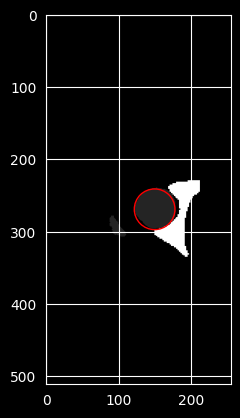

In [33]:
fig, ax = plt.subplots()
ax.imshow(left_leg.array[:, :, int(fhc[2])].T, cmap='gray')
circle = plt.Circle((fhc[0], fhc[1]), r_fh, color='r', fill=False)
ax.add_patch(circle)
plt.show()

In [34]:
def check_plausibility(trochanter_minor: np.ndarray) -> bool | float:
    """
    Check if the trochanter minor on the given layer is plausible.

    :return: Whether the trochanter minor is plausible.
    """
    tm = trochanter_minor.astype(np.int16)
    fh = fhc.astype(np.int16)

    tm_world = masks[0].transform_index_to_physical_point(tm)
    fh_world = masks[0].transform_index_to_physical_point(fh)
    tm_world = np.array([tm_world[0], tm_world[2]])  # exclude coronal axis?
    fh_world = np.array([fh_world[0], fh_world[2]])

    distance_world = np.linalg.norm(np.array(tm_world) - np.array(fh_world))

    return True if 75 > distance_world > 40 else distance_world

In [35]:
hip_mask.shape

(256, 512, 519)

In [36]:
isotropic = True

start, stop, step = (hip_mask.shape[0] - 1, 0, -1)
two_components_found = False
candidate_1, candidate_2 = False, False
components_large_enough = False
for layer in range(start, stop, step):
    connected_components = utils.extract_connected_components_2d(hip_mask[layer])
    if len(connected_components) == 2:
        two_components_found = True

        if isotropic and (np.count_nonzero(connected_components[0]) < 10 or np.count_nonzero(connected_components[1]) < 10):
            continue

        components_large_enough = True

        com_1 = center_of_mass(connected_components[0])
        com_2 = center_of_mass(connected_components[1])

        candidate_1 = np.array([layer, com_1[0], com_1[1]])
        candidate_2 = np.array([layer, com_2[0], com_2[1]])

        candidate_1 = check_plausibility(candidate_1)
        candidate_2 = check_plausibility(candidate_2)

        if (candidate_1 is not True) and (candidate_2 is not True):
            print(candidate_1, candidate_2)
            print(np.array([layer, com_1[0], com_1[1]]), np.array([layer, com_2[0], com_2[1]]))
            print('\n')
            continue

        break

In [37]:
candidate_1, candidate_2, layer

(True, 81.53507839819261, 227)

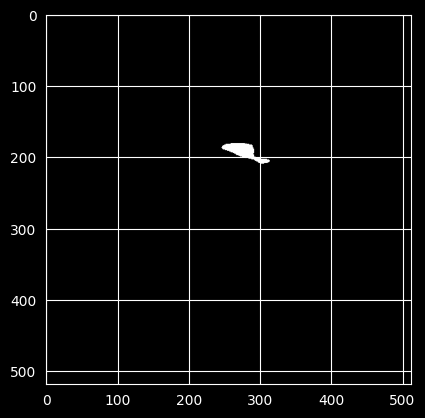

In [38]:
fig, ax = plt.subplots()
ax.imshow(hip_mask[135].T, cmap='gray')
plt.show()

## Implementation Test

In [39]:
import importlib
importlib.reload(femur)

<module 'morphometry.femur' from '/home/simon/Work/morphometry/morphometry/femur.py'>

In [40]:
_, masks = io.split_ct_image(left_leg, None)

Hip slices: 139 to 197, Knee slices: 319 to 338, Ankle slices: 426 to 464


186 205


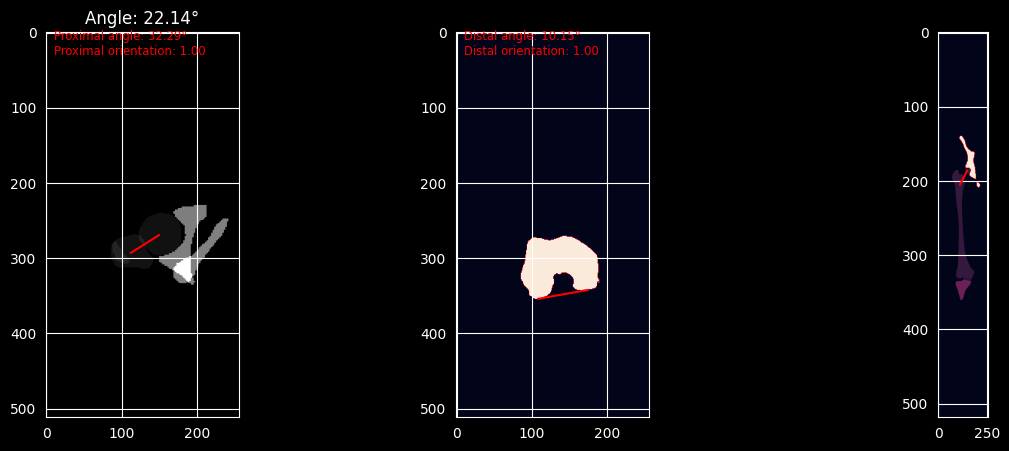

In [41]:
fig, ax = plt.subplots(ncols=3, figsize=(15, 5))
femur.calculate_femoral_torsion_ct(left_leg, masks[1], 'left', 1, ax)
plt.show()

In [42]:
_, masks = io.split_ct_image(right_leg, None)

Hip slices: 141 to 199, Knee slices: 320 to 338, Ankle slices: 426 to 464


188 206


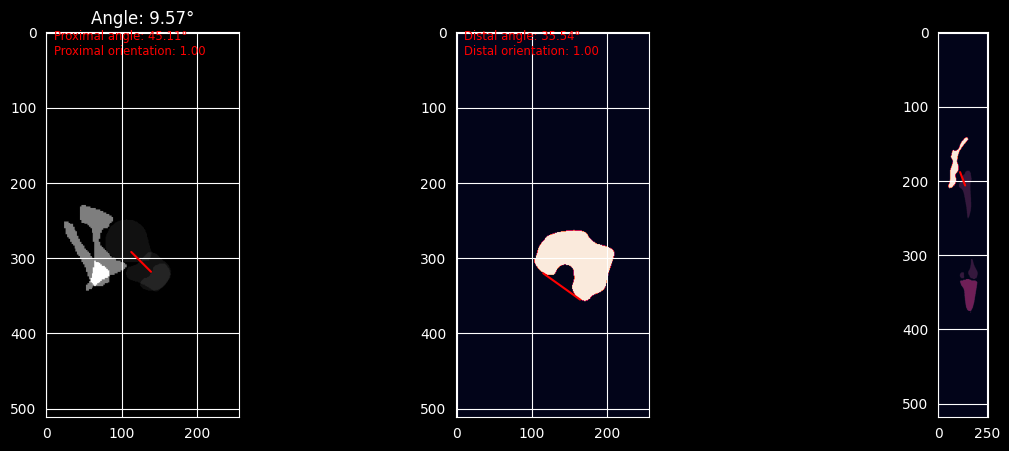

In [43]:
fig, ax = plt.subplots(ncols=3, figsize=(15, 5))
femur.calculate_femoral_torsion_ct(right_leg, masks[1], 'right', 1, ax)
plt.show()

# Tibial Torsion

## Implementation Test

In [44]:
from morphometry.tibia import calculate_tibial_torsion

In [45]:
_, masks = io.split_ct_image(left_leg, None)

Hip slices: 139 to 197, Knee slices: 319 to 338, Ankle slices: 426 to 464


22.97389354512196


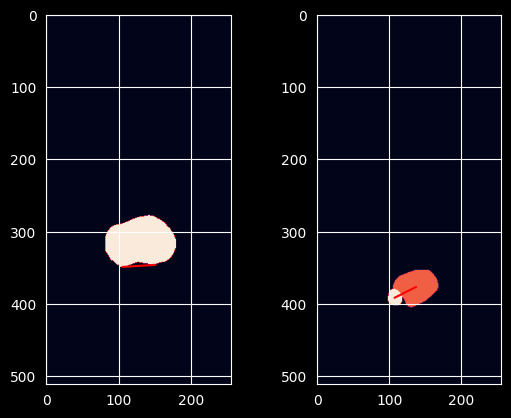

In [46]:
angle, fig = calculate_tibial_torsion(masks[1].array, masks[2].array, 2, 2, 3, 'left', True, False)
print(angle)
plt.show()

In [47]:
_, masks = io.split_ct_image(right_leg, None)

Hip slices: 141 to 199, Knee slices: 320 to 338, Ankle slices: 426 to 464


8.748698088122332


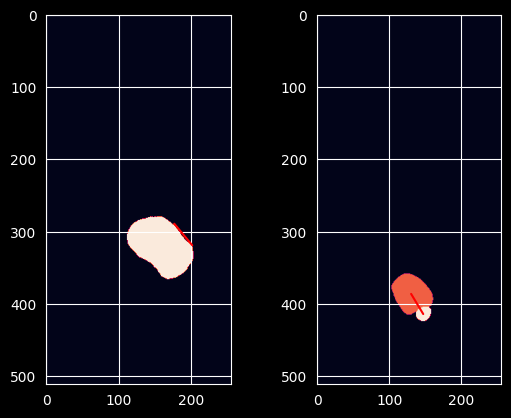

In [48]:
angle, fig = calculate_tibial_torsion(masks[1].array, masks[2].array, 2, 2, 3, 'right', True, False)
print(angle)
plt.show()

# Knee Rotation Angle

## Implementation Test

In [49]:
from morphometry.knee import calculate_knee_rotation_angle

In [50]:
_, masks = io.split_ct_image(left_leg, None)

Hip slices: 139 to 197, Knee slices: 319 to 338, Ankle slices: 426 to 464


6.422869581039768


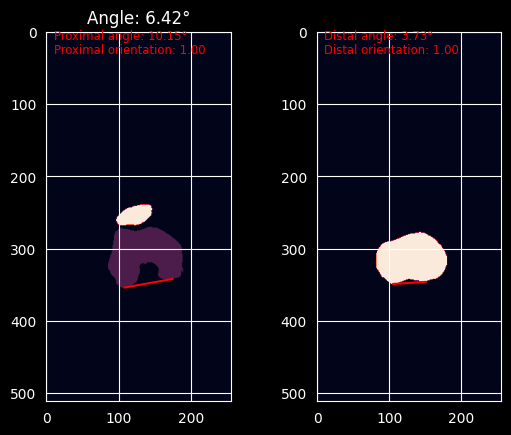

In [51]:
angle, fig = calculate_knee_rotation_angle(masks[1].array, 1, 2, 'left', True)
print(angle)
plt.show()

In [52]:
_, masks = io.split_ct_image(right_leg, None)

Hip slices: 141 to 199, Knee slices: 320 to 338, Ankle slices: 426 to 464


-14.656751115760414


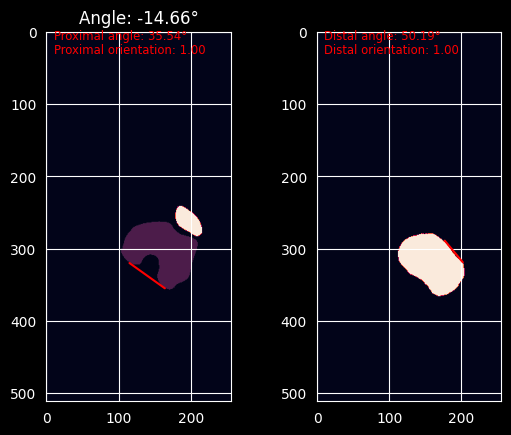

In [53]:
angle, fig = calculate_knee_rotation_angle(masks[1].array, 1, 2, 'right', True)
print(angle)
plt.show()

# Acetabular Anteversion

In [54]:
from morphometry.hip import get_femoral_head_center_ct

In [55]:
left_mask = seg.array[:seg.array.shape[0] // 2]
right_mask = seg.array[seg.array.shape[0] // 2:]

In [56]:
left_image = nib.Nifti1Image(left_mask, seg.affine, seg.header)
right_image = nib.Nifti1Image(right_mask, seg.affine, seg.header)
left_image = io.Segmentation.from_nibabel(left_image)
right_image = io.Segmentation.from_nibabel(right_image)

In [57]:
_, left_fhc = get_femoral_head_center_ct(left_image, segmentation_label=1, side='left')
_, right_fhc = get_femoral_head_center_ct(right_image, segmentation_label=1, side='right')

In [58]:
left_fhc = left_image.transform_physical_point_to_index(left_fhc)
right_fhc = right_image.transform_physical_point_to_index(right_fhc)
print(left_fhc, right_fhc)

[149.83924987 269.08544463 186.86028106] [112.75541455 291.65210988 188.14204311]


In [59]:
slice_gap = abs(int(left_fhc[2]) - int(right_fhc[2]))
correct_slice = min(int(left_fhc[2]), int(right_fhc[2])) + slice_gap // 2
print(correct_slice)

187


In [60]:
acetabulum_array = np.where(left_image.array[:, :, correct_slice] == 7, 1, 0)
acetabulum_array[:, :int(left_fhc[1])] = 0
p1 = np.argwhere(acetabulum_array == 1)
p1 = p1[p1[:, 0].argmin()]
print(p1)

[152 298]


## Implementation Test

In [61]:
import importlib
importlib.reload(hip)

<module 'morphometry.hip' from '/home/simon/Work/morphometry/morphometry/hip.py'>

In [62]:
_, masks = io.split_ct_image(seg, None)

Hip slices: 139 to 197, Knee slices: 319 to 338, Ankle slices: 426 to 464


Left: 11.685791875974305
Right: 21.830862803270904


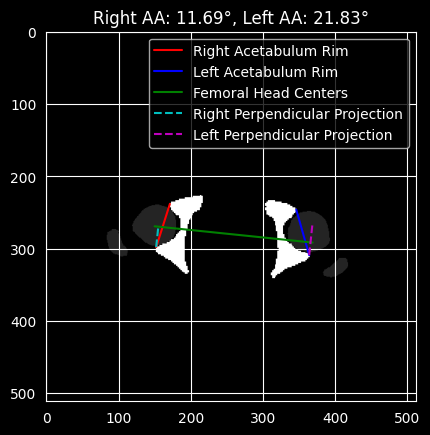

In [63]:
fig, ax = plt.subplots()
left_angle, right_angle = hip.calculate_acetabular_anteversion(masks[0], 1, 7, isotropic=True, ct=True, plot=ax)
print('Left:', left_angle)
print('Right:', right_angle)
plt.show()

# Center-Edge Angle

## Implementation Test

In [64]:
importlib.reload(hip)
importlib.reload(io)

<module 'morphometry.image_io' from '/home/simon/Work/morphometry/morphometry/image_io.py'>

In [65]:
image = io.Image('nibabel')
image.read_image('/home/simon/Data/NMDID/test_combined_0000.nii.gz')
image.transform_coordinate_system()
images, masks = io.split_ct_image(seg, image)

Hip slices: 139 to 197, Knee slices: 319 to 338, Ankle slices: 426 to 464


In [66]:
import tempfile
tmp_file = tempfile.NamedTemporaryFile(suffix='.nii.gz', delete=False)
images[0].save_image(tmp_file.name)

Left: 58.858951956797156
Right: 58.839532933190476


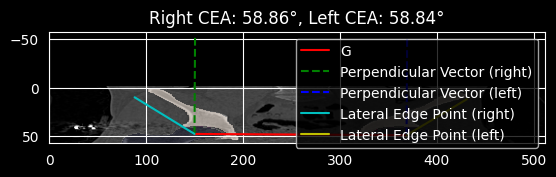

In [67]:
fig, ax = plt.subplots()
left_angle, right_angle = hip.calculate_center_edge_angle(masks[0], 1, 7, isotropic=True, ct=True, project=True, plot=ax, image_path=tmp_file.name)
print('Left:', left_angle)
print('Right:', right_angle)
plt.show()

# Femoral Offset

## Implementation Test

In [68]:
importlib.reload(hip)

<module 'morphometry.hip' from '/home/simon/Work/morphometry/morphometry/hip.py'>

In [69]:
hip.calculate_femoral_offset_projected(left_leg, side='left', femur_label=1, isotropic=True, ct=True)

34.874080923446535

In [70]:
hip.calculate_femoral_offset_projected(right_leg, side='right', femur_label=1, isotropic=True, ct=True)

22.967615416041873

# Mechanical Axis Deviation

## Implementation Test

In [71]:
import morphometry.whole_leg as whole_leg

In [75]:
importlib.reload(whole_leg)

<module 'morphometry.whole_leg' from '/home/simon/Work/morphometry/morphometry/whole_leg.py'>

In [76]:
whole_leg.calculate_mechanical_axis_deviation(left_leg, side='left')

Hip slices: 139 to 197, Knee slices: 319 to 338, Ankle slices: 426 to 464
Hip slices: 139 to 197, Knee slices: 319 to 338, Ankle slices: 426 to 464
[0. 1. 2. 5.]


9.80132513399739

In [77]:
whole_leg.calculate_mechanical_axis_deviation(right_leg, side='right')

Hip slices: 141 to 199, Knee slices: 320 to 338, Ankle slices: 426 to 464
Hip slices: 141 to 199, Knee slices: 320 to 338, Ankle slices: 426 to 464
[0. 1. 2. 5.]


25.009174972712966

# Joint Line Convergence Angle

In [4]:
_, masks = io.split_ct_image(left_leg, None)
left_knee = masks[1]
_, masks = io.split_ct_image(right_leg, None)
right_knee = masks[1]

Hip slices: 139 to 197, Knee slices: 319 to 338, Ankle slices: 426 to 464
Hip slices: 141 to 199, Knee slices: 320 to 338, Ankle slices: 426 to 464


## Femoral Reference Line

Idea: Use the femoral condyles to define the femoral reference line for the JLCA measurement.
Problem: How to separate left and right condyles?

1. Iterate proximal -> distal until two connected components are found.
2. Set flag_1 = True
3. Iterate proximal -> distal until only one connected component is found.
4. Set flag_2 = True
5. Iterate distal -> proximal until two connected components are found.
6. If flag_1 and flag_2 are True, compute the centroid of the smaller component on that slice as condyle center.

For the second condyle:
1. Find the most distal slice where only one connected component is found.
2. Compute the centroid of that component as condyle center.

In [11]:
array = left_knee.array.copy()
array = np.where(array == 1, 1, 0)

In [12]:
flag_1 = False
flag_2 = False
i = 0
while i < left_knee.shape[2]:
    layer = array[:, :, i]
    connected_components = utils.extract_connected_components_2d(layer)
    if len(connected_components) == 2:
        flag_1 = True
    if flag_1 and len(connected_components) == 1:
        flag_2 = True
        break
    i += 1

if not (flag_1 and flag_2):
    raise RuntimeError('Could not find condyles!')

i = left_knee.shape[2] - 1
flag_1 = False
while i >= 0:
    layer = array[:, :, i]
    connected_components = utils.extract_connected_components_2d(layer)
    if len(connected_components) == 2:
        flag_1 = True
        break

    i -= 1

if not flag_1:
    raise RuntimeError('Could not find condyles!')

condyle_1 = center_of_mass(connected_components[0]) if np.count_nonzero(connected_components[0]) < np.count_nonzero(connected_components[1]) else center_of_mass(connected_components[1])
condyle_1 = np.array([condyle_1[0], condyle_1[1], i])

In [13]:
i = left_knee.shape[2] - 1
flag_1 = False
while i >= 0:
    layer = array[:, :, i]
    connected_components = utils.extract_connected_components_2d(layer)
    if len(connected_components) == 1:
        flag_1 = True
        break

    i -= 1

if not flag_1:
    raise RuntimeError('Could not find condyles!')

condyle_2 = center_of_mass(connected_components[0])
condyle_2 = np.array([condyle_2[0], condyle_2[1], i])

In [14]:
condyle_1, condyle_2

(array([106.23892405, 316.6835443 ,  13.        ]),
 array([163.19130435, 304.26956522,  15.        ]))

In [17]:
proximal_reference_line = condyle_1 - condyle_2

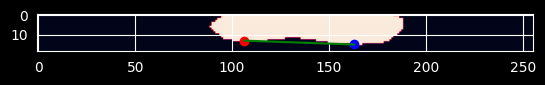

In [18]:
fig, ax = plt.subplots()
ax.imshow(array[:, (int(condyle_1[1]) + int(condyle_2[1])) // 2].T)
ax.plot(condyle_1[0], condyle_1[2], 'ro')
ax.plot(condyle_2[0], condyle_2[2], 'bo')
ax.plot([condyle_1[0], condyle_2[0]], [condyle_1[2], condyle_2[2]], 'g-')
plt.show()

## Tibial Reference Line

Idea: The tibial plateau, on which the reference line should be defined, is the slice with the largest mediolateral extent of the tibia.

1. Iterate proximal -> distal, compute the mediolateral extent of the tibia on each slice by fitting PCA with one component to the voxel coordinates, which is the longest possible line from one contour point to another.
2. Find the slice with the largest mediolateral extent.
3. The reference line is the lined defined by the principal component fitted to the contour points on that slice.

In [19]:
array = left_knee.array.copy()
array = np.where(array == 2, 1, 0)

In [22]:
from sklearn.decomposition import PCA


max_length = -1
slice_index = -1
final_line_start = None
final_line_end = None

for i in range(array.shape[2]):
    layer = array[:, :, i]

    coordinates = np.argwhere(layer == 1)

    if len(coordinates) == 0:
        continue

    pca = PCA(n_components=1)
    pca.fit(coordinates)

    projected_coordinates = pca.transform(coordinates)
    min_projection = np.min(projected_coordinates)
    max_projection = np.max(projected_coordinates)

    line_direction = pca.components_[0]
    line_start = pca.mean_ + min_projection * line_direction
    line_end = pca.mean_ + max_projection * line_direction

    line_length = np.linalg.norm(line_end - line_start)

    if line_length > max_length:
        max_length = line_length
        slice_index = i
        final_line_start = line_start
        final_line_end = line_end

In [24]:
final_line_start, final_line_end, slice_index

(array([ 81.59111869, 319.345799  ]), array([179.62516173, 310.73330295]), 17)

In [25]:
start = np.array([final_line_start[0], final_line_start[1], slice_index])
end = np.array([final_line_end[0], final_line_end[1], slice_index])

In [26]:
distal_reference_line = end - start

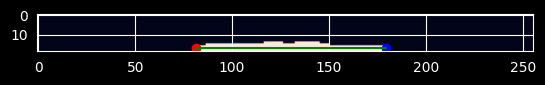

In [27]:
fig, ax = plt.subplots()
ax.imshow(array[:, (int(start[1]) + int(end[1])) // 2].T)
ax.plot(start[0], start[2], 'ro')
ax.plot(end[0], end[2], 'bo')
ax.plot([start[0], end[0]], [start[2], end[2]], 'g-')
plt.show()

*Problem: this way, the reference line will always be horizontal, which doesn't accurately reflect the anatomy.*

New idea:
1. Find the intercondylar eminence (centroid of the first segmented slice) and divide the tibial plateau into medial and lateral halves.
2. Find the most lateral point in the lateral half and the most medial point in the medial half.
3. Compute the distances d_1 and d_2 between the eminence and those two points.
4. Restrict the search space to all points laterally of the eminence by >d_1 and medially of the eminence by >d_2.
5. Find the most proximal medial and lateral points in that restricted search space.

In [44]:
# 1. Find the intercondylar eminence (centroid of the first segmented slice) and divide the tibial plateau into medial and lateral halves.
array = left_knee.array.copy()
array = np.where(array == 2, 1, 0)

if np.count_nonzero(array) == 0:
    raise ValueError('No tibia found!')

i = 0
while i < array.shape[2]:
    layer = array[:, :, i]
    if np.count_nonzero(layer) > 0:
        break
    i += 1

eminence = center_of_mass(layer)
eminence = np.array([eminence[0], eminence[1], i])

# 2. Find the most lateral point in the lateral half and the most medial point in the medial half.
# Note for later: need to handle side correctly, we will call the sides left and right for now
# Since we are working with the left image, the left half is lateral and the right half is medial
points = np.argwhere(array == 1)
most_lateral = points[points[:, 0].argmin()]
most_lateral = np.array([most_lateral[0], most_lateral[1], i])
most_medial = points[points[:, 0].argmax()]
most_medial = np.array([most_medial[0], most_medial[1], i])

# 3. Compute the distances d_1 and d_2 between the eminence and those two points.
d_1 = np.linalg.norm(most_lateral - eminence)
d_2 = np.linalg.norm(most_medial - eminence)

# 4. Restrict the search space to all points laterally of the eminence by >d_1 * 2/3 and medially of the eminence by >d_2 * 2/3.
left_points = points[points[:, 0] < (eminence[0] - d_1 * 2 / 3)]
right_points = points[points[:, 0] > (eminence[0] + d_2 * 2 / 3)]

# 5. Find the most proximal medial and lateral points in that restricted search space.
lateral_point = left_points[left_points[:, 2].argmin()]
lateral_point = np.array([lateral_point[0], lateral_point[1], lateral_point[2]])
medial_point = right_points[right_points[:, 2].argmin()]
medial_point = np.array([medial_point[0], medial_point[1], medial_point[2]])

In [45]:
lateral_point, medial_point

(array([ 85, 320,  15]), array([165, 325,  15]))

In [46]:
distal_reference_line = medial_point - lateral_point

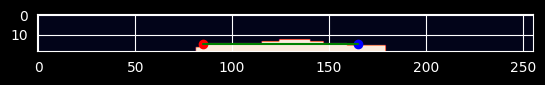

In [47]:
fig, ax = plt.subplots()
ax.imshow(array[:, (int(lateral_point[1]) + int(medial_point[1])) // 2].T)
ax.plot(lateral_point[0], lateral_point[2], 'ro')
ax.plot(medial_point[0], medial_point[2], 'bo')
ax.plot([lateral_point[0], medial_point[0]], [lateral_point[2], medial_point[2]], 'g-')
plt.show()

## Implementation Test

In [52]:
import morphometry.knee as knee

In [56]:
importlib.reload(knee)

<module 'morphometry.knee' from '/home/simon/Work/morphometry/morphometry/knee.py'>

2.011232685749718

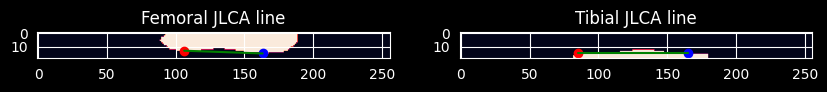

In [57]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 10))
knee.calculate_joint_line_convergence_angle(left_knee, 1, 2, 'left', plot=ax)

1.6817338148919252

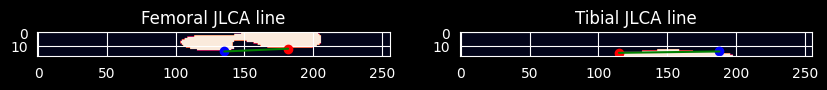

In [58]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 10))
knee.calculate_joint_line_convergence_angle(right_knee, 1, 2, 'right', plot=ax)

# Hip Knee Ankle Angle

## Implementation Test

In [60]:
import morphometry.whole_leg as whole_leg

In [61]:
importlib.reload(whole_leg)

<module 'morphometry.whole_leg' from '/home/simon/Work/morphometry/morphometry/whole_leg.py'>

In [62]:
whole_leg.calculate_hip_knee_ankle_angle(left_leg)

Hip slices: 139 to 197, Knee slices: 319 to 338, Ankle slices: 426 to 464
Hip slices: 139 to 197, Knee slices: 319 to 338, Ankle slices: 426 to 464


168.36149724762936

In [63]:
whole_leg.calculate_hip_knee_ankle_angle(right_leg, side='right')

Hip slices: 141 to 199, Knee slices: 320 to 338, Ankle slices: 426 to 464
Hip slices: 141 to 199, Knee slices: 320 to 338, Ankle slices: 426 to 464


154.4666986390647